In [49]:
import matplotlib.pyplot as plt
from factor_diffusion_sample import generate_rejection
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
from factor_model import *
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from scenario_generator import *
import numpy as np

with open("cfg.yaml") as f:
    _exp = yaml.safe_load(f)["experiment_name"]
PREFIX = f"model/{_exp}"
with open(f"{PREFIX}/cfg.yaml") as f:
    _cfg = yaml.safe_load(f)

FACTOR_NAMES = _cfg["factor_names"]
NUM_GENERATE = _cfg["num_generate"]
print(f"experiment: {_exp}")

experiment: DDPM


In [50]:
def plot_vol_panel(ax, xlim, title_suffix, datasets, fidx, threshold=None):
    for label, data, color in datasets:
        col     = data[:, fidx] if data.ndim == 2 else data
        clipped = col[(col >= xlim[0]) & (col <= xlim[1])]
        if len(clipped) < 2:
            continue
        ax.hist(clipped, bins=40, density=True, alpha=0.55,
                color=color, label=label, edgecolor="white", linewidth=0.4)
        kde = gaussian_kde(col, bw_method=0.3)
        x_grid = np.linspace(xlim[0], xlim[1], 400)
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=2)

    if threshold is not None:
        ax.axvline(threshold, color="black", linestyle="--", linewidth=1.5,
                   label=f"threshold = {threshold:.4f}")
    ax.set_xlabel(FACTOR_NAMES[fidx])
    ax.set_ylabel("density")
    ax.set_xlim(xlim)
    ax.set_title(title_suffix)
    ax.legend(fontsize=8, framealpha=0.9)
    for i, (label, data, color) in enumerate(datasets):
        col     = data[:, fidx] if data.ndim == 2 else data
        pct     = (col <= threshold).mean() * 100 if threshold is not None else float("nan")
        visible = ((col >= xlim[0]) & (col <= xlim[1])).sum()
        ax.text(0.02, 0.97 - i * 0.10,
                f"{label}: {pct:.0f}% <= thr  ({visible}/{len(col)} visible)",
                transform=ax.transAxes, fontsize=8,
                color=color, va="top")

-  max is increasing via sample size and it is not stable in market factor
- N = 4096 other fatcor are stable

In [51]:
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_TIMESTEPS = _cfg["num_timesteps"]
LEVY_ALPHA    = _cfg["levy_alpha"]
BATCH_SIZE    = _cfg["batch_size"]
FACTOR_DIM    = len(_cfg["factor_names"])
CHECKPOINT    = f"{PREFIX}/checkpoints/{_cfg['ckpt_name']}.pt"
print(CHECKPOINT)

model/DDPM/checkpoints/DLPM_L.pt


In [52]:
# util functions
def _to_norm(scaler, value, idx):
    dummy = np.zeros((1, FACTOR_DIM))
    dummy[0, idx] = value
    return float(scaler.transform(dummy)[0, idx])

def make_cond_fn(interval, scaler, feature_idx=0, normalize=True):
    thl, thr = interval

    if normalize:
        qmax_norm = _to_norm(scaler, thr, feature_idx)

        def cond_fn(x0_hat):
            return torch.relu(x0_hat[:, feature_idx] - qmax_norm) ** 2
    else:
        def cond_fn(x0_hat):
            return torch.relu(x0_hat[:, feature_idx] - thr) ** 2

    cond_fn.label = f"{FACTOR_NAMES[feature_idx]} < {thr:.4f}"

    return cond_fn


In [53]:
# load achievements
"""
ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model = FactorDenoiser(**ckpt["model_kwargs"]).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
gammas, bargammas, sigmas, barsigmas = levy_noise_schedule(LEVY_ALPHA, NUM_TIMESTEPS)
scaler = ckpt["scaler"]
args   = (model, gammas, bargammas, sigmas, barsigmas, LEVY_ALPHA, scaler)

"""

'\nckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)\nmodel = FactorDenoiser(**ckpt["model_kwargs"]).to(DEVICE)\nmodel.load_state_dict(ckpt["model_state"])\ngammas, bargammas, sigmas, barsigmas = levy_noise_schedule(LEVY_ALPHA, NUM_TIMESTEPS)\nscaler = ckpt["scaler"]\nargs   = (model, gammas, bargammas, sigmas, barsigmas, LEVY_ALPHA, scaler)\n\n'

In [54]:
"""
Ns = [128, 256, 512, 1028, 2048, 4096, 10000]
uncons = [generate(*args, num_samples=N) for N in Ns]
maxns = [np.max(uncon[0], axis=0) for uncon in uncons]
maxns
q3s   = [np.percentile(uncon[0], 3, axis=0) for uncon in uncons]
qmins = [uncon[0].min(axis=0) for uncon in uncons]
fidx  = FACTOR_NAMES.index("momentum")
conds = []
for q3, qmin in zip(q3s, qmins):
    cond = make_cond_fn((qmin[fidx], q3[fidx]), scaler, fidx)
    conds.append(cond)

cons  = [generate(*args, cond_fn=c, guidance_scale=GUIDANCE_S, num_samples=n)
         for c, n in zip(conds, Ns)]
maxns = [np.max(con[0], axis) for con in cons]
maxns
"""

'\nNs = [128, 256, 512, 1028, 2048, 4096, 10000]\nuncons = [generate(*args, num_samples=N) for N in Ns]\nmaxns = [np.max(uncon[0], axis=0) for uncon in uncons]\nmaxns\nq3s   = [np.percentile(uncon[0], 3, axis=0) for uncon in uncons]\nqmins = [uncon[0].min(axis=0) for uncon in uncons]\nfidx  = FACTOR_NAMES.index("momentum")\nconds = []\nfor q3, qmin in zip(q3s, qmins):\n    cond = make_cond_fn((qmin[fidx], q3[fidx]), scaler, fidx)\n    conds.append(cond)\n\ncons  = [generate(*args, cond_fn=c, guidance_scale=GUIDANCE_S, num_samples=n)\n         for c, n in zip(conds, Ns)]\nmaxns = [np.max(con[0], axis) for con in cons]\nmaxns\n'

In [55]:
# unconditional sample and conditional config
GUIDANCE_S = 5 # guidance scale
N = 4096 # sample number
train_model = load_model(f"{PREFIX}")
diffusionScenario = ScenarioGenerator(train_model, DiffusionSampler(CHECKPOINT, guidance_scale = GUIDANCE_S))


In [56]:
uncon = diffusionScenario.factor_generate(N)
uncon.shape

(4096, 7)

In [57]:
#momentum < 3% quantile
q3   = np.percentile(uncon, 3,  axis=0)
qmin = uncon.min(axis=0)
fidx = FACTOR_NAMES.index("momentum")

lower003_fn  = make_cond_fn((qmin[fidx], q3[fidx]), diffusionScenario.sampler.scaler, fidx)
lower003 = diffusionScenario.cond_factor_generate(N, lower003_fn)
print(lower003_fn.label)

momentum < -0.0042


In [58]:
lower003_fn.label

'momentum < -0.0042'

In [59]:
gaussion_model = load_model("model/Gaussion")
gaussionScenario = ScenarioGenerator(gaussion_model, GaussianSampler(gaussion_model.F, diffusionScenario.sampler.scaler, guidance_scale=GUIDANCE_S))
sampled_gaussian = gaussionScenario.cond_factor_generate(N, lower003_fn)

In [60]:
resampledScenario = ScenarioGenerator(train_model, ResampleSampler(train_model.F, diffusionScenario.sampler.scaler, guidance_scale=GUIDANCE_S))
sampled_train = resampledScenario.cond_factor_generate(N, lower003_fn)

In [61]:
REJ_CACHE = f"{PREFIX}/samples/rej_{_cfg['ckpt_name']}_N{N}_s{GUIDANCE_S}.npy"
if os.path.exists(REJ_CACHE):
    rej = np.load(REJ_CACHE)
    print(f"Loaded cached rej samples from {REJ_CACHE}  shape={rej.shape}")
else:
    print("Cache not found, running rejection sampling (slow)...")
    rej = generate_rejection(diffusionScenario.sampler.model, diffusionScenario.sampler.scaler, cond_fn=lower003_fn,
                             num_samples=N, guidance_scale=GUIDANCE_S, L = diffusionScenario.sampler.L)
    np.save(REJ_CACHE, rej)
    print(f"Saved to {REJ_CACHE}  shape={rej.shape}")

Loaded cached rej samples from model/DDPM/samples/rej_DLPM_L_N4096_s5.npy  shape=(4096, 7)


In [62]:
COLORS = {
    "uncon":     "#888888",
    "con":       "#2196F3",
    "rej":       "#FF5722",
    "gaussion":  "#4CAF50",
    "train":     "#FFC107"
}

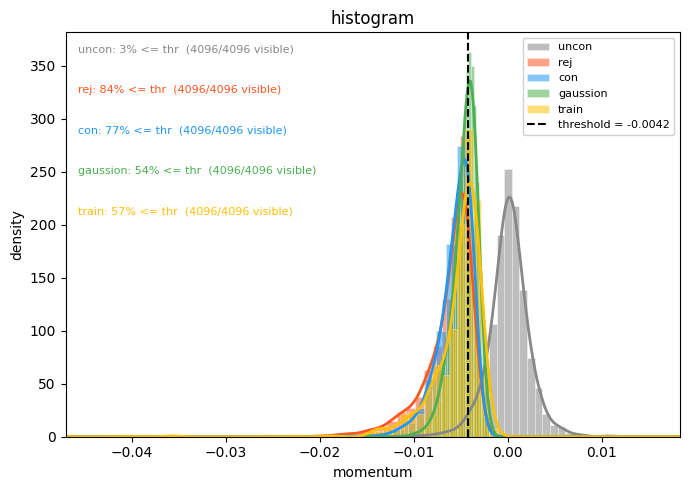

In [63]:
datasets_hist = [
    ("uncon", uncon,    COLORS["uncon"]),
    ("rej",   rej,      COLORS["rej"]),
    ("con",   lower003, COLORS["con"]),
    ("gaussion", sampled_gaussian, COLORS["gaussion"]),
    ("train", sampled_train, COLORS["train"]),
]
all_data = np.concatenate([d[:, fidx] for _, d, _ in datasets_hist])
full_lim = (all_data.min() - abs(all_data.min()) * 0.05,
            all_data.max() + abs(all_data.max()) * 0.05)
fig2, ax_full = plt.subplots(figsize=(7, 5))
plot_vol_panel(ax_full, full_lim, "histogram", datasets_hist, fidx=fidx, threshold=q3[fidx])
fig2.tight_layout()
plt.show()

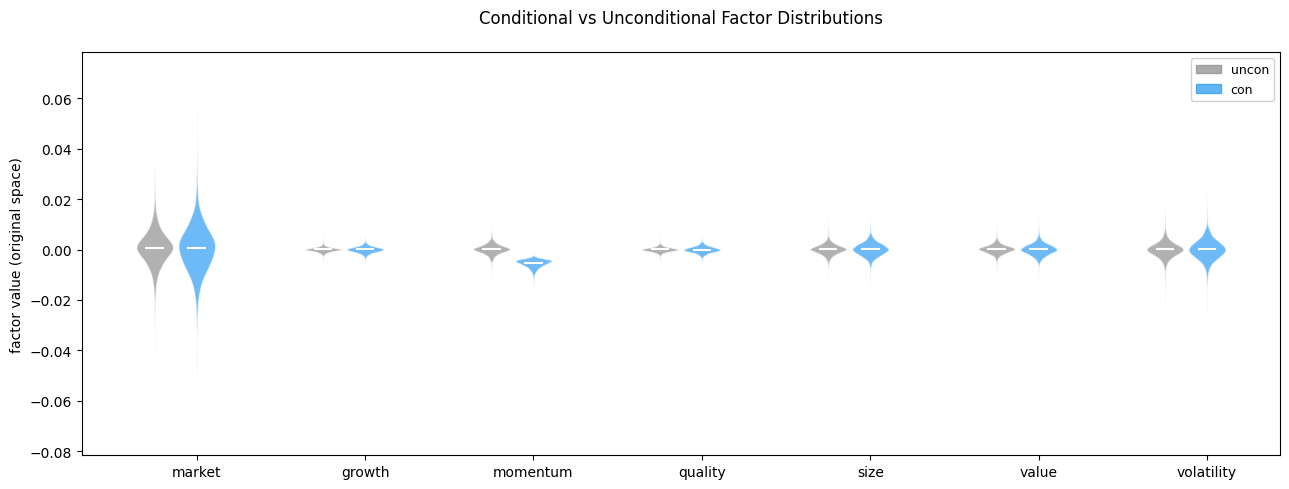

In [64]:
datasets = [
    ("uncon", uncon,    COLORS["uncon"]),
  #  ("rej",   rej,      "#FF5722"),
    ("con",   lower003, COLORS["con"]),
]
x_center = np.arange(FACTOR_DIM)
offsets  = [-0.25, 0.0, 0.25]
fig, ax = plt.subplots(figsize=(13, 5))

for offset, (label, data, color) in zip(offsets, datasets):
    parts = ax.violinplot(
        [data[:, i] for i in range(FACTOR_DIM)],
        positions=x_center + offset,
        widths=0.22,
        showmedians=True,
        showextrema=False,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_edgecolor("white")
        pc.set_alpha(0.65)
    parts["cmedians"].set_color("white")
    parts["cmedians"].set_linewidth(1.5)

ax.set_xticks(x_center)
ax.set_xticklabels(FACTOR_NAMES, fontsize=10)
ax.set_ylabel("factor value (original space)")
ax.set_title(
    f"Conditional vs Unconditional Factor Distributions\n"
)

handles = [mpatches.Patch(color=c, alpha=0.7, label=l) for l, _, c in datasets]
ax.legend(handles=handles, fontsize=9, framealpha=0.9)

fig.tight_layout()
plt.show()

### Correlation Heatmaps - Unconditional vs Conditional

In [65]:
def corr_mat(data):
    return np.corrcoef(data, rowvar=False)

corr_uncon    = corr_mat(uncon)
corr_rej      = corr_mat(rej)
corr_low      = corr_mat(lower003)
corr_gaussion = corr_mat(sampled_gaussian)
corr_train    = corr_mat(train_model.F.drop(columns=['alpha']).values)

In [66]:
# --- load historical factor data ---
hist = pd.read_csv(f"{PREFIX}/factors.csv", index_col=0, parse_dates=True)
# drop alpha column if present
hist = hist[[c for c in hist.columns if c in FACTOR_NAMES]]
hist = hist[FACTOR_NAMES]   # align column order

# --- filter historical days matching condition: momentum < q3[fidx] ---
mom_thresh = q3[fidx]       # same threshold used to generate lower003
hist_stress = hist[hist.iloc[:, fidx] < mom_thresh].values
gen_stress  = lower003      # (N, FACTOR_DIM)

print(f"Historical stress days:  {len(hist_stress)}")
print(f"Generated stress samples: {len(gen_stress)}")
print(f"Momentum threshold: {mom_thresh:.4f}")

Historical stress days:  250
Generated stress samples: 4096
Momentum threshold: -0.0042


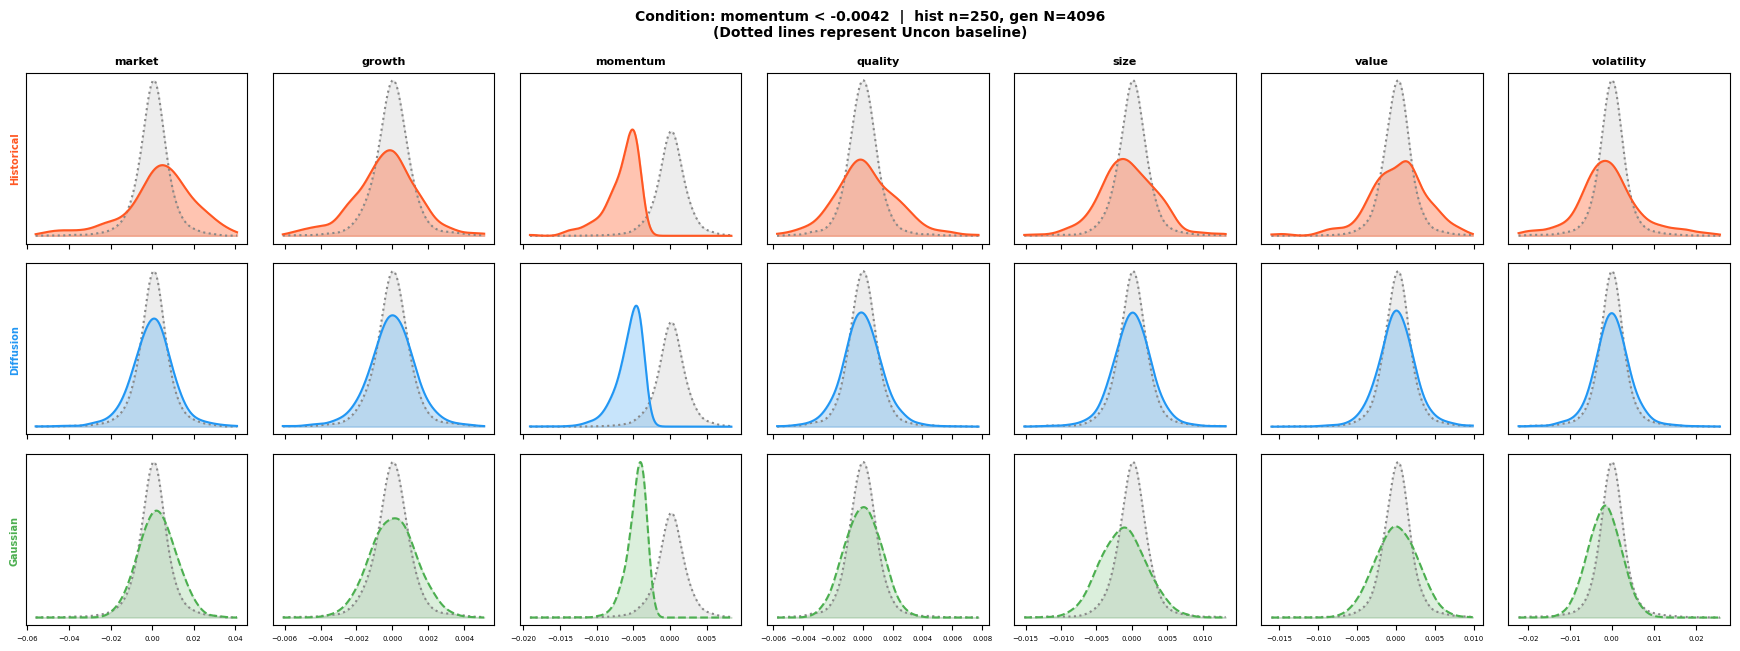

In [67]:
methods_to_plot = [
    ("Historical",      hist_stress,      "#FF5722",      "-",  0.35),
    ("Diffusion",       lower003,         COLORS["con"],  "-",  0.25),
   # ("Rejection",       rej,              COLORS["rej"],  "--", 0.20),
    ("Gaussian",        sampled_gaussian, COLORS["gaussion"], "--", 0.20),
]

uncon_label, uncon_data, uncon_color, uncon_ls, uncon_alpha = ("Uncon", uncon, COLORS["uncon"], ":", 0.15)

nrows = len(methods_to_plot)
ncols = FACTOR_DIM


fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.2),
                         sharex="col", sharey="col")


all_datasets = [d for _, d, _, _, _ in methods_to_plot] + [uncon_data]
x_grids = []
for i in range(ncols):
    cols = [d[:, i] for d in all_datasets]
    xlo  = min(np.percentile(c, 0.5)  for c in cols)
    xhi  = max(np.percentile(c, 99.5) for c in cols)
    pad  = (xhi - xlo) * 0.05
    x_grids.append(np.linspace(xlo - pad, xhi + pad, 400))


for r, (label, data, color, ls, alpha) in enumerate(methods_to_plot):
    for i, name in enumerate(FACTOR_NAMES):
        ax  = axes[r, i]
        x_grid = x_grids[i]


        col_uncon = uncon_data[:, i]
        kde_uncon = gaussian_kde(col_uncon, bw_method=0.3)
        ax.fill_between(x_grid, kde_uncon(x_grid), alpha=uncon_alpha, color=uncon_color)
        ax.plot(x_grid, kde_uncon(x_grid), color=uncon_color, linewidth=1.5, linestyle=uncon_ls)


        col_method = data[:, i]
        kde_method = gaussian_kde(col_method, bw_method=0.3)
        ax.fill_between(x_grid, kde_method(x_grid), alpha=alpha, color=color)
        ax.plot(x_grid, kde_method(x_grid), color=color, linewidth=1.5, linestyle=ls)


        ax.set_yticks([])
        ax.tick_params(labelsize=5)

        if r == 0:
            ax.set_title(name, fontsize=8, fontweight="bold")
        if i == 0:
            ax.set_ylabel(label, fontsize=7, color=color, fontweight="bold")

fig.suptitle(
    f"Condition: momentum < {mom_thresh:.4f}  |  hist n={len(hist_stress)}, gen N={N}\n"
    f"(Dotted lines represent Uncon baseline)",
    fontsize=10, fontweight="bold"
)
plt.tight_layout()
plt.show()


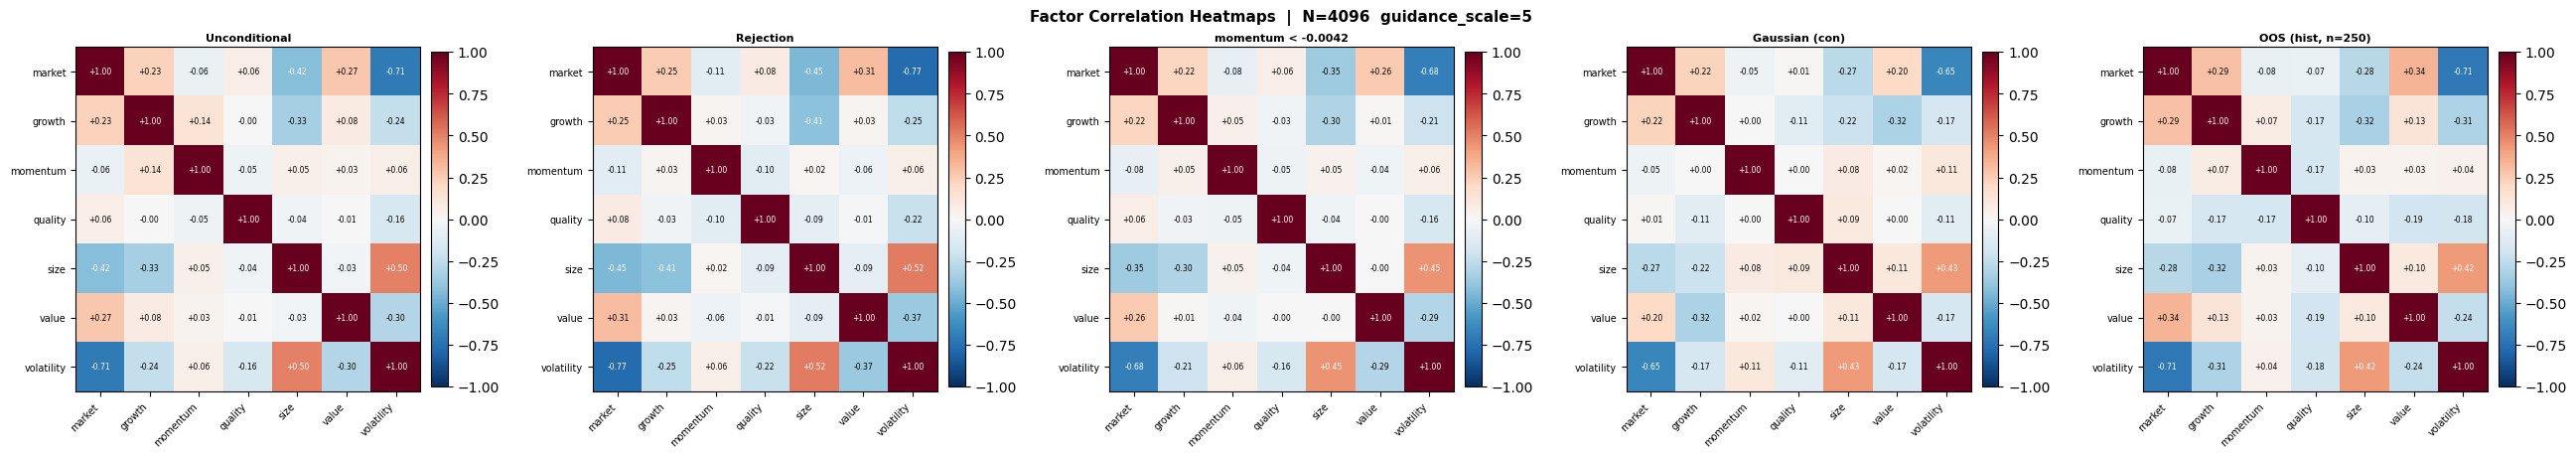

In [68]:
corr_hist = corr_mat(hist_stress)

all_panels = [
    ("Unconditional",    corr_uncon),
    ("Rejection",        corr_rej),
    (lower003_fn.label,  corr_low),
    ("Gaussian (con)",   corr_gaussion),
    (f"OOS (hist, n={len(hist_stress)})", corr_hist),
]

norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
fig, axes = plt.subplots(1, 5, figsize=(26, 4.5), constrained_layout=True)

for ax, (name, corr) in zip(axes, all_panels):
    im = ax.imshow(corr, cmap="RdBu_r", norm=norm, aspect="equal")
    ax.set_xticks(range(FACTOR_DIM))
    ax.set_yticks(range(FACTOR_DIM))
    ax.set_xticklabels(FACTOR_NAMES, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(FACTOR_NAMES, fontsize=7)
    ax.set_title(name, fontweight="bold", fontsize=8, pad=4)
    for ii in range(FACTOR_DIM):
        for jj in range(FACTOR_DIM):
            ax.text(jj, ii, f"{corr[ii,jj]:+.2f}",
                    ha="center", va="center", fontsize=5.5,
                    color="white" if abs(corr[ii,jj]) > 0.4 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

fig.suptitle(
    f"Factor Correlation Heatmaps  |  N={N}  guidance_scale={GUIDANCE_S}",
    fontsize=11, fontweight="bold"
)
plt.show()


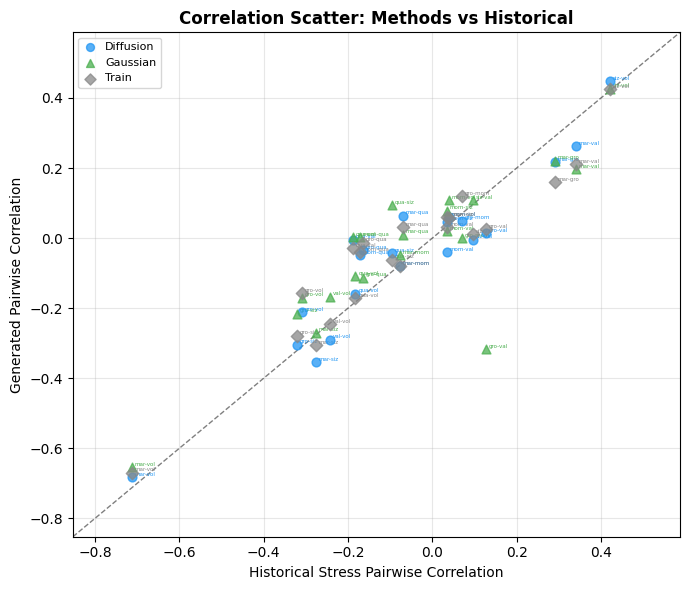

In [69]:
import itertools

idx_pairs   = list(itertools.combinations(range(FACTOR_DIM), 2))
pair_labels = [f"{FACTOR_NAMES[i][:3]}-{FACTOR_NAMES[j][:3]}" for i, j in idx_pairs]

def upper_tri(corr):
    return np.array([corr[i, j] for i, j in idx_pairs])

hist_vec = upper_tri(corr_hist)
methods  = [
    ("Diffusion",  upper_tri(corr_low),       COLORS["con"],      "o"),
   # ("Rejection",        upper_tri(corr_rej),       COLORS["rej"],      "s"),
    ("Gaussian",   upper_tri(corr_gaussion),  COLORS["gaussion"], "^"),
    ("Train",            upper_tri(corr_train),     COLORS["uncon"],    "D"),
]

all_vecs = [hist_vec] + [v for _, v, _, _ in methods]
lim = [min(v.min() for v in all_vecs), max(v.max() for v in all_vecs)]
pad = (lim[1] - lim[0]) * 0.12 or 0.05
lim = [lim[0] - pad, lim[1] + pad]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(lim, lim, "k--", lw=1, alpha=0.5)

for label, vec, color, mk in methods:
    ax.scatter(hist_vec, vec, color=color, s=40, marker=mk,
               zorder=4, label=label, alpha=0.75)
    for k, lbl in enumerate(pair_labels):
        ax.annotate(lbl, (hist_vec[k], vec[k]),
                    fontsize=4, xytext=(2, 1),
                    textcoords="offset points", color=color)

ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Historical Stress Pairwise Correlation", fontsize=10)
ax.set_ylabel("Generated Pairwise Correlation", fontsize=10)
ax.set_title("Correlation Scatter: Methods vs Historical", fontweight="bold")
ax.legend(fontsize=8, markerscale=0.9, handlelength=1.2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [70]:
from metrics.statistic import compute_cov
print("Relative Frobenius Distance of Covariance Matrix")
print(f"  {'Train':<16} {compute_cov(train_model.F.drop(columns=['alpha']).values, hist_stress):.4f}")
print(f"  {'Diffusion':<16} {compute_cov(lower003, hist_stress):.4f}")
print(f"  {'Gaussion':<16} {compute_cov(sampled_gaussian, hist_stress):.4f}")

corr_uncon    = corr_mat(uncon)
corr_rej      = corr_mat(rej)
corr_low      = corr_mat(lower003)
corr_gaussion = corr_mat(sampled_gaussian)
corr_train    = corr_mat(train_model.F.drop(columns=['alpha']).values)

Relative Frobenius Distance of Covariance Matrix
  Train            0.7431
  Diffusion        0.6295
  Gaussion         0.7450


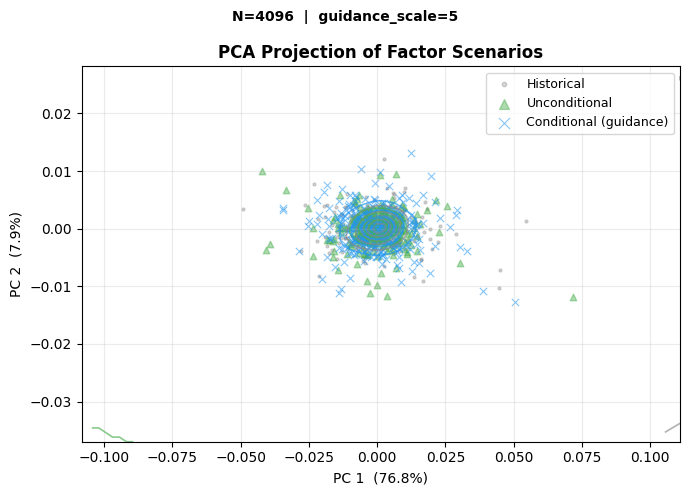

In [71]:
from factor_model import load_model, reconstruct_returns

# --- load factor model ---
train_model = load_model(f"{PREFIX}")

# --- generated stress stock returns ---
fs_gen = np.column_stack([
    np.ones((len(lower003), 1), dtype=np.float32),
    lower003.astype(np.float32),
])
R_gen_stress = reconstruct_returns(train_model, fs_gen)   # (N, S)

# --- historical stock returns on stress days ---
stress_mask   = train_model.F["momentum"].values < q3[fidx]
fs_hist       = train_model.F.values[stress_mask].astype(np.float32)
R_hist_stress = reconstruct_returns(train_model, fs_hist)  # (T_stress, S)


train_vals = hist.values  # (T, 7)

pca = PCA(n_components=2)
pca.fit(train_vals)

train_pc = pca.transform(train_vals)
uncon_pc = pca.transform(uncon)
con_pc   = pca.transform(lower003)

xlab = f"PC 1  ({pca.explained_variance_ratio_[0]*100:.1f}%)"
ylab = f"PC 2  ({pca.explained_variance_ratio_[1]*100:.1f}%)"

N_SUB = 300

def _sub(arr, n=N_SUB, seed=0):
    idx = np.random.default_rng(seed).choice(len(arr), size=min(n, len(arr)), replace=False)
    return arr[idx]

def _contour(ax, pc, color, levels=5, lw=1.2):
    kde = gaussian_kde(pc.T)
    pad = (pc.max(axis=0) - pc.min(axis=0)) * 0.15
    lo, hi = pc.min(axis=0) - pad, pc.max(axis=0) + pad
    xx, yy = np.mgrid[lo[0]:hi[0]:80j, lo[1]:hi[1]:80j]
    z = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contour(xx, yy, z, levels=levels, colors=[color], alpha=0.65, linewidths=lw)

COLORS_PCA = {
    "train": "#888888",
    "uncon": "#4CAF50",
    "con":   "#2196F3",
}
fig, ax = plt.subplots(figsize=(7, 5))
_contour(ax, train_pc, COLORS_PCA["train"])
_contour(ax, uncon_pc, COLORS_PCA["uncon"])
_contour(ax, con_pc,   COLORS_PCA["con"])
ax.scatter(*_sub(train_pc, seed=0).T, c=COLORS_PCA["train"], marker=".",  s=18, alpha=0.35, label="Historical")
ax.scatter(*_sub(uncon_pc, seed=1).T, c=COLORS_PCA["uncon"], marker="^",  s=22, alpha=0.45, label="Unconditional")
ax.scatter(*_sub(con_pc,   seed=2).T, c=COLORS_PCA["con"],   marker="x",  s=28, alpha=0.55, label="Conditional (guidance)", linewidths=0.8)
ax.set_xlabel(xlab); ax.set_ylabel(ylab)
ax.set_title("PCA Projection of Factor Scenarios", fontweight="bold")
ax.legend(fontsize=9, markerscale=1.5)
ax.grid(True, alpha=0.25)

fig.suptitle(
    f"N={N}  |  guidance_scale={GUIDANCE_S}",
    fontsize=10, fontweight="bold"
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_16192/2771927498.py:53: UserWarning: You passed a edgecolor/edgecolors ('#D62728') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(beta_mom, ER, s=34, alpha=0.55, color=color, marker=mk,


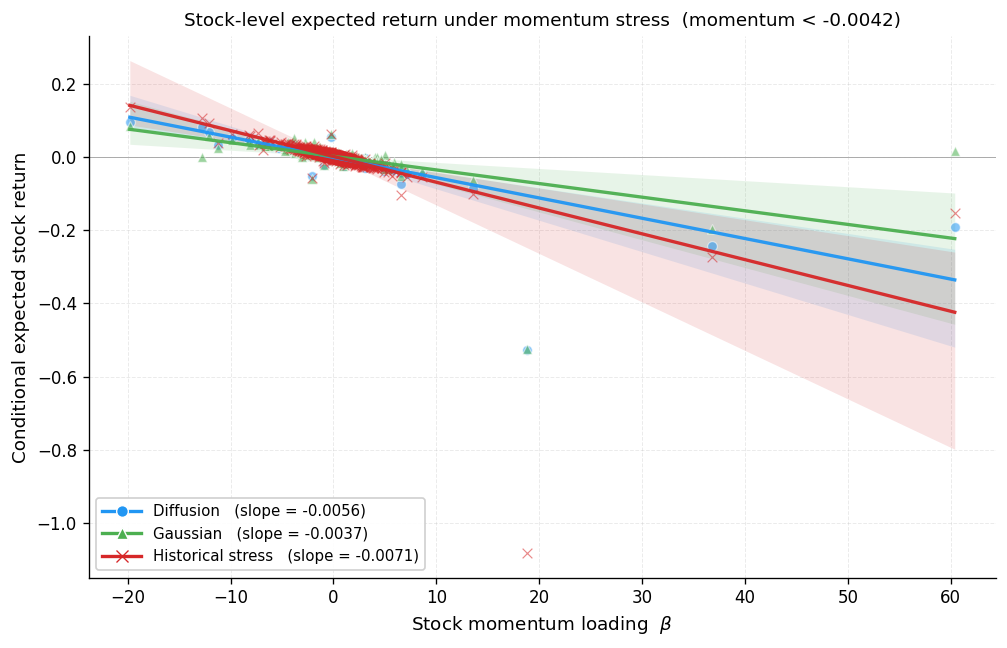

In [77]:
# Review.pdf 12.1.C.3 — Stock-level scatter: beta vs conditional expected return
from matplotlib.lines import Line2D

beta_cols    = list(train_model.F.columns)            # ["alpha", "market", "growth", ...]
beta_mom_idx = beta_cols.index("momentum")
beta_mom     = train_model.beta[beta_mom_idx, :]      # (S,)

# Reuse the conditional factor samples already drawn in earlier cells
# (lower003, sampled_gaussian) and reconstruct stock returns through train_model.
def _to_returns(factors):
    fs = np.column_stack([np.ones((len(factors), 1), dtype=np.float32),
                          factors.astype(np.float32)])
    return reconstruct_returns(train_model, fs)

R_diff_cond  = _to_returns(lower003)
R_gauss_cond = _to_returns(sampled_gaussian)

# Historical stress-day reconstruction (apples-to-apples)
stress_mask  = train_model.F["momentum"].values < q3[fidx]
R_hist_cond  = reconstruct_returns(
    train_model, train_model.F.values[stress_mask].astype(np.float32)
)

ER_diff  = R_diff_cond.mean(axis=0)
ER_gauss = R_gauss_cond.mean(axis=0)
ER_hist  = R_hist_cond.mean(axis=0)

def _fit_with_ci(x, y, n_boot=300, seed=0):
    m, b = np.polyfit(x, y, 1)
    xs   = np.linspace(x.min(), x.max(), 100)
    rng  = np.random.default_rng(seed)
    n    = len(x)
    preds = np.empty((n_boot, xs.size))
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        mi, bi = np.polyfit(x[idx], y[idx], 1)
        preds[i] = mi * xs + bi
    lo, hi = np.percentile(preds, [2.5, 97.5], axis=0)
    return xs, m * xs + b, m, lo, hi

series = [
    ("Diffusion",         ER_diff,  COLORS["con"],      "o"),
    ("Gaussian",          ER_gauss, COLORS["gaussion"], "^"),
    ("Historical stress", ER_hist,  "#D62728",          "x"),
]

fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=120)
ax.axhline(0, color="0.35", lw=0.6, alpha=0.5, zorder=1)

handles = []
for label, ER, color, mk in series:
    edge = color if mk == "x" else "white"  # 'x' has no fill — edge carries the color
    ax.scatter(beta_mom, ER, s=34, alpha=0.55, color=color, marker=mk,
               edgecolors=edge, linewidths=0.7, zorder=3)
    xs, ys, slope, lo, hi = _fit_with_ci(beta_mom, ER)
    ax.fill_between(xs, lo, hi, color=color, alpha=0.13, zorder=2, linewidth=0)
    ax.plot(xs, ys, color=color, lw=2.0, alpha=0.95, zorder=4)
    handles.append(Line2D(
        [0], [0], color=color, lw=2, marker=mk, markersize=7,
        markerfacecolor="none" if mk == "x" else color,
        markeredgecolor=color if mk == "x" else "white",
        markeredgewidth=0.8,
        label=f"{label}   (slope = {slope:+.4f})",
    ))

ax.set_xlabel(r"Stock momentum loading  $\beta$", fontsize=11)
ax.set_ylabel("Conditional expected stock return", fontsize=11)
ax.set_title(
    f"Stock-level expected return under momentum stress  "
    f"(momentum < {q3[fidx]:.4f})",
    fontsize=11,
)
ax.legend(handles=handles, fontsize=9, frameon=True, framealpha=0.92,
          loc="lower left", handlelength=2.6)
ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.6)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()